# GOOD DAY FEATURES

Цель — для каждого сохранённого out-of-time forecast origin `T` получить причинные характеристики текущего курса и ожидаемого сожаления на горизонте пяти **quote observations**. Курс измеряется как RUB за единицу валюты получателя: чем он ниже, тем выгоднее отправителю RUB. CatBoost здесь не переобучается.

## 1. Входные артефакты и определения

Используются сохранённые CatBoost-прогнозы и базовый feature dataset. `favourability_percentile_90` переиспользуется в его исходном причинном определении: `1 - mean(P_i <= P_T)` для строго предыдущих `T-90...T-1`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.good_day_features import PREDICTED, plot_favourable_decile, run_good_day_features

required = [
    'notebooks/04_catboost_multihorizon_forecasting.ipynb',
    'reports/catboost_multihorizon_test_predictions.csv',
    'docs/base_feature_dictionary.md',
    'data/features/base_market_features.parquet',
]
inventory = pd.DataFrame({'artifact': required, 'exists': [(ROOT / p).exists() for p in required]})
display(inventory)
if not inventory['exists'].all(): raise FileNotFoundError(inventory.loc[~inventory.exists, 'artifact'].tolist())

,artifact,exists
0,notebooks/04_catboost_multihorizon_forecasting...,True
1,reports/catboost_multihorizon_test_predictions...,True
2,docs/base_feature_dictionary.md,True
3,data/features/base_market_features.parquet,True


## 2. Формулы

- `past_best_5 = min(P_(T-5), ..., P_(T-1))`; текущая котировка исключена.
- `past_advantage_5 = (past_best_5 - rate_t) / past_best_5`. Положительное значение означает, что сегодня выгоднее прошлого пятиточечного минимума.
- `predicted_future_best_5 = min(predicted_rate_h1, ..., predicted_rate_h5)`.
- `predicted_regret_5 = max(0, (rate_t - predicted_future_best_5) / rate_t)`. Чем меньше, тем сильнее аргумент действовать сегодня.

`actual_future_best_5` и `actual_regret_5` сохраняются исключительно как `EVALUATION_ONLY`; они не участвуют ни в одном прогнозном признаке.

In [2]:
run = run_good_day_features(ROOT)
print('Feature history:', run['feature_path'].relative_to(ROOT))
print('Saved forecasts:', run['prediction_path'].relative_to(ROOT))
print('CatBoost retrained: NO')
print('Rows:', len(run['output']))
print('Corridors:', ', '.join(sorted(run['output'].corridor.unique())))

Feature history: data\features\base_market_features.parquet
Saved forecasts: reports\catboost_multihorizon_test_predictions.csv
CatBoost retrained: NO
Rows: 1375
Corridors: AMD_RUB, KGS_RUB, KZT_RUB, TJS_RUB, UZS_RUB


## 3. Проверка alignment и итоговая схема

In [3]:
print('rate_t сопоставлен с rate на той же date=T внутри corridor: PASS')
print('Predictions уже относятся к origin T и повторно не сдвигались: PASS')
display(run['output'].head())
print('Columns:')
print('\n'.join(run['output'].columns))

rate_t сопоставлен с rate на той же date=T внутри corridor: PASS
Predictions уже относятся к origin T и повторно не сдвигались: PASS


,corridor,date,rate_t,favourability_percentile_90,past_best_5,past_advantage_5,predicted_rate_h1,predicted_rate_h2,predicted_rate_h3,predicted_rate_h4,predicted_rate_h5,predicted_future_best_5,predicted_regret_5,actual_future_best_5,actual_regret_5
0,AMD_RUB,2025-07-12,0.202874,0.988889,0.203010,0.000670,0.202853,0.202686,0.202847,0.202994,0.203031,0.202686,0.000924,0.202953,0.000000
1,AMD_RUB,2025-07-15,0.204020,0.877778,0.202874,-0.005649,0.204181,0.204205,0.204233,0.204244,0.204307,0.204181,0.000000,0.202953,0.005230
2,AMD_RUB,2025-07-16,0.202953,0.966667,0.202874,-0.000389,0.202754,0.202757,0.203003,0.203110,0.203150,0.202754,0.000982,0.203038,0.000000
3,AMD_RUB,2025-07-17,0.203038,0.944444,0.202874,-0.000808,0.203039,0.203011,0.203045,0.203230,0.203229,0.203011,0.000132,0.203371,0.000000
4,AMD_RUB,2025-07-18,0.203545,0.877778,0.202874,-0.003307,0.203654,0.203685,0.203742,0.203798,0.203870,0.203654,0.000000,0.203371,0.000855


Columns:
corridor
date
rate_t
favourability_percentile_90
past_best_5
past_advantage_5
predicted_rate_h1
predicted_rate_h2
predicted_rate_h3
predicted_rate_h4
predicted_rate_h5
predicted_future_best_5
predicted_regret_5
actual_future_best_5
actual_regret_5


## 4. Human sanity check

Для фиксированной выборки показаны предыдущие пять реальных котировок, текущий курс, прогнозный путь и рассчитанные величины.

In [4]:
display(run['human_check'])

,corridor,date,rate_t,previous_5_rates,favourability_percentile_90,past_best_5,past_advantage_5,predicted_rate_h1,predicted_rate_h2,predicted_rate_h3,predicted_rate_h4,predicted_rate_h5,predicted_future_best_5,predicted_regret_5,actual_future_best_5,actual_regret_5
503,KGS_RUB,2026-06-17,0.824915,"[0.837789, 0.820264, 0.820926, 0.822272, 0.828...",0.855556,0.820264,-0.005670,0.823934,0.824842,0.824768,0.824946,0.824874,0.823934,0.001189,0.831880,0.000000
67,AMD_RUB,2025-10-15,0.208895,"[0.214136, 0.213058, 0.21281, 0.212161, 0.211346]",0.511111,0.211346,0.011597,0.208489,0.208536,0.208814,0.208866,0.209075,0.208489,0.001942,0.206023,0.013749
916,TJS_RUB,2025-11-19,8.732080,"[8.76693, 8.75928, 8.68601, 8.74276, 8.74389]",0.388889,8.686010,-0.005304,8.733831,8.734609,8.737886,8.740572,8.737672,8.733831,0.000000,8.493810,0.027287
643,KZT_RUB,2025-11-21,0.155430,"[0.153628, 0.154729, 0.155365, 0.154643, 0.155...",0.044444,0.153628,-0.011730,0.155391,0.155408,0.155399,0.155400,0.155380,0.155380,0.000320,0.150864,0.029377
240,AMD_RUB,2026-07-03,0.211649,"[0.205384, 0.209337, 0.211253, 0.212753, 0.212...",0.188889,0.205384,-0.030504,0.211496,0.211804,0.211687,0.211998,0.211964,0.211496,0.000723,0.206826,0.022788


## 5. Summary без выбора good-day threshold

In [5]:
display(run['summary'])

,corridor,n_rows,n_valid_favourability_90,n_valid_past_advantage_5,mean_favourability_90,median_favourability_90,mean_past_advantage_5,median_past_advantage_5,mean_predicted_regret_5,median_predicted_regret_5
0,AMD_RUB,275,275,275,0.498747,0.466667,-0.011025,-0.007779,0.000491,0.000000
1,KGS_RUB,275,275,275,0.552121,0.533333,-0.010501,-0.007131,0.000611,0.000205
2,KZT_RUB,275,275,275,0.418747,0.322222,-0.013689,-0.010105,0.000747,0.000421
3,TJS_RUB,275,275,275,0.477212,0.388889,-0.011413,-0.008436,0.000274,0.000000
4,UZS_RUB,275,275,275,0.485899,0.422222,-0.012619,-0.010263,0.000783,0.000628


## 6. Минимальная визуальная проверка

Оранжевые точки — верхние 10% уже рассчитанного `favourability_percentile_90` внутри доступного out-of-time периода. Это не разметка `good_day` и не подбор порога.

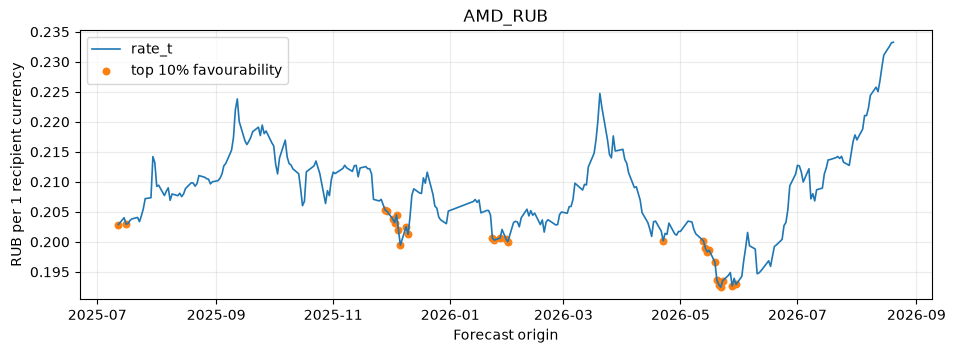

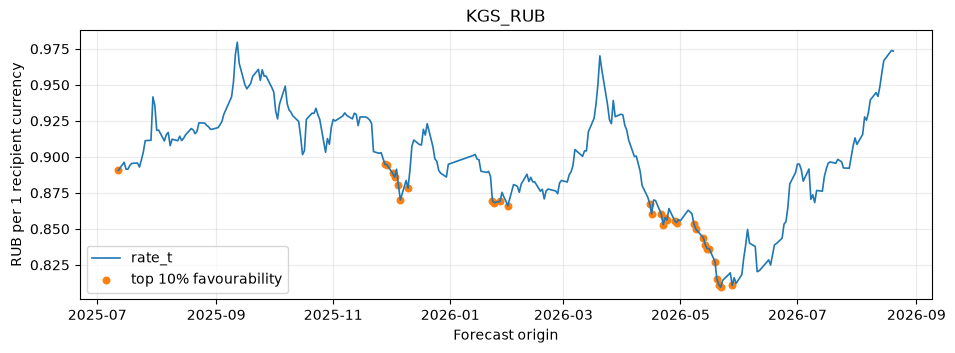

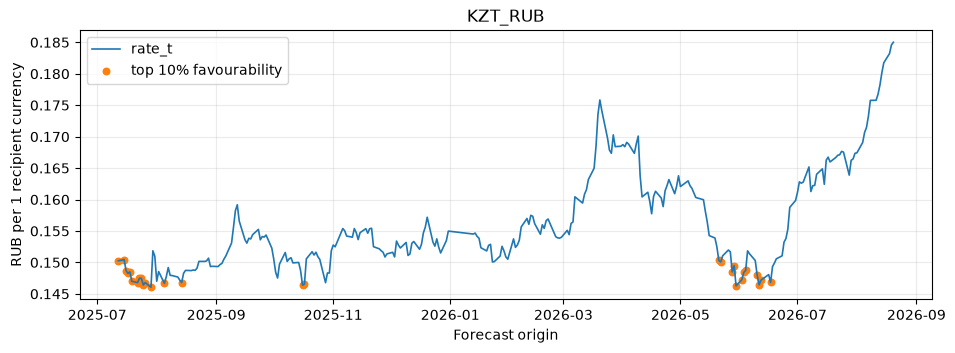

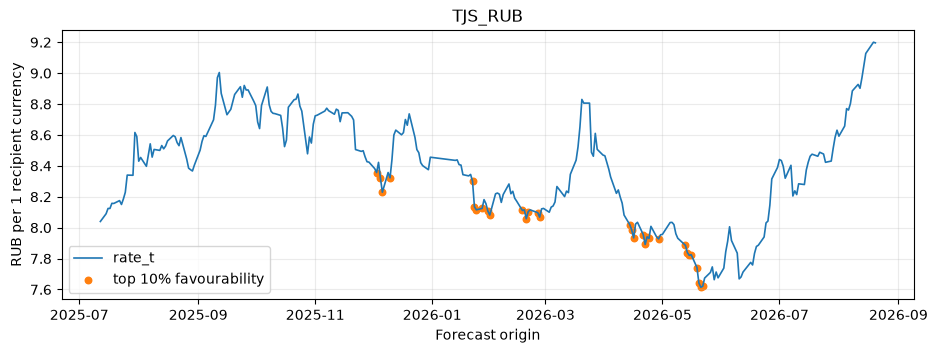

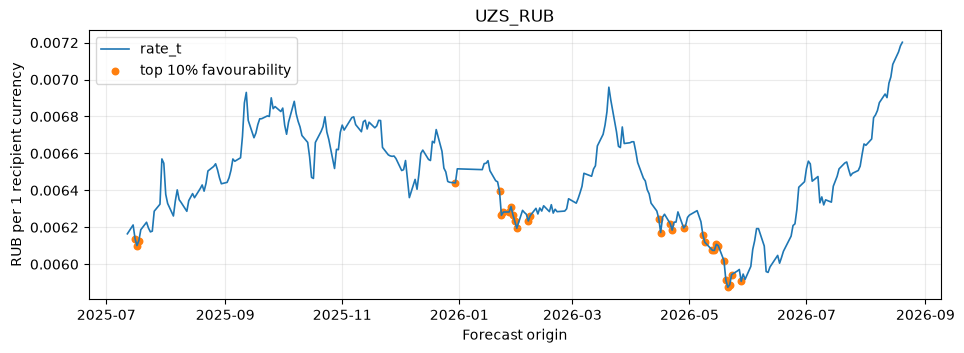

In [6]:
plot_favourable_decile(run['output'])

## 7. Leakage check

In [7]:
display(run['leakage'])
leakage_status = 'PASS' if run['leakage'].passed.all() else 'FAIL'
print(f'GOOD DAY FEATURE LEAKAGE CHECK: {leakage_status}')

,check,passed
0,favourability uses only T-90...T-1,True
1,"favourability is in [0,1]",True
2,past_best_5 uses only T-5...T-1,True
3,past_advantage uses no future data,True
4,predicted_future_best uses predicted H1...H5 only,True
5,predicted_regret is non-negative,True
6,predicted_regret uses no actual H1...H5,True
7,all operations grouped by corridor,True
8,no centered windows,True
9,no negative shifts in predicted features,True


GOOD DAY FEATURE LEAKAGE CHECK: PASS


## 8. Final output

In [8]:
print(f"GOOD DAY FEATURE STAGE: {run['status']}")
print('Created: favourability_percentile_90, past_best_5, past_advantage_5, predicted_future_best_5, predicted_regret_5')
print('Rows:', len(run['output']))
print('Corridors:', ', '.join(sorted(run['output'].corridor.unique())))
print('Leakage:', leakage_status)
print('Output:', run['output_path'].relative_to(ROOT))

GOOD DAY FEATURE STAGE: PASS
Created: favourability_percentile_90, past_best_5, past_advantage_5, predicted_future_best_5, predicted_regret_5
Rows: 1375
Corridors: AMD_RUB, KGS_RUB, KZT_RUB, TJS_RUB, UZS_RUB
Leakage: PASS
Output: reports\good_day_features.csv
